# Generación de Texto con modelos GPT — Fine-tuning en Reseñas de Hoteles

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/Ohtar10/icesi-nlp/blob/main/Sesion3/1-transformers-from-scratch.ipynb)

En este notebook utilizamos **`Amloii/gpt2-reviewspanish`**, un modelo GPT-2 pre-entrenado específicamente sobre reseñas en español.

La idea de este notebook es generar reseñas de hoteles a partir de un modelo pre-entrenado en reviews de productos al cual se le realiza finetuning con un dataset de reviews de hoteles.

Se realizó este ejercicio con el fin balancear un dataset de reviews de hoteles que estamos utilizando para el trabajo de grado, debido a que es dificil encontrar data en español.

#### Referencias
- Modelo base: https://huggingface.co/Amloii/gpt2-reviewspanish
- Dataset: `Balanced_AHR.csv` — reseñas balanceadas de hoteles en español

---

### *Entregado por:*


*   Laura Isabel Chaparro Navia
*   Ricardo Chicangana
*   Fabian Ortiz Collazos

In [ ]:
import pkg_resources
import warnings

warnings.filterwarnings('ignore')

installed_packages = [package.key for package in pkg_resources.working_set]
IN_COLAB = 'google-colab' in installed_packages

C:\Users\rchic\AppData\Local\Temp\ipykernel_42992\2396000874.py:1: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  import pkg_resources


## Generative pre-training Transformer - GPT

![](https://github.com/Ohtar10/icesi-nlp/blob/main/assets/gpt.png?raw=1)

En este notebook usamos **`Amloii/gpt2-reviewspanish`**, un modelo GPT-2 con 124 millones de parámetros que fue pre-entrenado sobre un corpus extenso de reseñas en español. Esto le da un sesgo natural hacia el lenguaje de opinión: palabras como *"recomiendo"*, *"decepcionante"*, *"excelente servicio"* tendrán mayor probabilidad que en un GPT-2 de propósito general.

In [ ]:
import torch
import transformers
from transformers import AutoModelForCausalLM, AutoTokenizer


device = "cuda" if torch.cuda.is_available() else "cpu"
model_name = "Amloii/gpt2-reviewspanish"
tokenizer = AutoTokenizer.from_pretrained(model_name)
model = AutoModelForCausalLM.from_pretrained(model_name).to(device)

if tokenizer.pad_token is None:
  tokenizer.pad_token = tokenizer.eos_token

model.config.pad_token_id = tokenizer.pad_token_id

model.resize_token_embeddings(len(tokenizer))

model

Loading weights:   0%|          | 0/149 [00:00<?, ?it/s]

The tied weights mapping and config for this model specifies to tie transformer.wte.weight to lm_head.weight, but both are present in the checkpoints, so we will NOT tie them. You should update the config with `tie_word_embeddings=False` to silence this warning
GPT2LMHeadModel LOAD REPORT from: Amloii/gpt2-reviewspanish
Key                                     | Status     |  | 
----------------------------------------+------------+--+-
transformer.h.{0...11}.attn.masked_bias | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


GPT2LMHeadModel(
  (transformer): GPT2Model(
    (wte): Embedding(50257, 768)
    (wpe): Embedding(1024, 768)
    (drop): Dropout(p=0.1, inplace=False)
    (h): ModuleList(
      (0-11): 12 x GPT2Block(
        (ln_1): LayerNorm((768,), eps=1e-05, elementwise_affine=True)
        (attn): GPT2Attention(
          (c_attn): Conv1D(nf=2304, nx=768)
          (c_proj): Conv1D(nf=768, nx=768)
          (attn_dropout): Dropout(p=0.1, inplace=False)
          (resid_dropout): Dropout(p=0.1, inplace=False)
        )
        (ln_2): LayerNorm((768,), eps=1e-05, elementwise_affine=True)
        (mlp): GPT2MLP(
          (c_fc): Conv1D(nf=3072, nx=768)
          (c_proj): Conv1D(nf=768, nx=3072)
          (act): NewGELUActivation()
          (dropout): Dropout(p=0.1, inplace=False)
        )
      )
    )
    (ln_f): LayerNorm((768,), eps=1e-05, elementwise_affine=True)
  )
  (lm_head): Linear(in_features=768, out_features=50257, bias=False)
)

In [ ]:
# Mostramos la cantidad de parametros del modelo
total_params = sum(p.numel() for p in model.parameters())
print(f"Cantidad total de parámetros del modelo: {total_params:,}")

Cantidad total de parámetros del modelo: 124,439,808


In [ ]:
modules = [m for m, _ in model.named_modules()]
modules

['',
 'transformer',
 'transformer.wte',
 'transformer.wpe',
 'transformer.drop',
 'transformer.h',
 'transformer.h.0',
 'transformer.h.0.ln_1',
 'transformer.h.0.attn',
 'transformer.h.0.attn.c_attn',
 'transformer.h.0.attn.c_proj',
 'transformer.h.0.attn.attn_dropout',
 'transformer.h.0.attn.resid_dropout',
 'transformer.h.0.ln_2',
 'transformer.h.0.mlp',
 'transformer.h.0.mlp.c_fc',
 'transformer.h.0.mlp.c_proj',
 'transformer.h.0.mlp.act',
 'transformer.h.0.mlp.dropout',
 'transformer.h.1',
 'transformer.h.1.ln_1',
 'transformer.h.1.attn',
 'transformer.h.1.attn.c_attn',
 'transformer.h.1.attn.c_proj',
 'transformer.h.1.attn.attn_dropout',
 'transformer.h.1.attn.resid_dropout',
 'transformer.h.1.ln_2',
 'transformer.h.1.mlp',
 'transformer.h.1.mlp.c_fc',
 'transformer.h.1.mlp.c_proj',
 'transformer.h.1.mlp.act',
 'transformer.h.1.mlp.dropout',
 'transformer.h.2',
 'transformer.h.2.ln_1',
 'transformer.h.2.attn',
 'transformer.h.2.attn.c_attn',
 'transformer.h.2.attn.c_proj',
 'tran

Observemos un ejemplo de generación simple con el modelo base.

In [ ]:
text = "Fue una curiosa"
best = 10

with torch.no_grad():
    tokens = tokenizer(text, return_tensors='pt')['input_ids'].to(device)
    print("Dimensiones de la entrada:", tokens.shape)
    output = model(input_ids=tokens)
    print("Dimensiones de la salida:", output.logits.shape)
    output = output.logits[0, -1, :]
    print("Dimensiones del último token de la secuencia:", output.shape)
    probs = torch.softmax(output, dim=-1)
    print("Dimensiones de la probabilidad de los tokens:", probs.shape)
    sorted_probs = torch.argsort(probs, dim=-1, descending=True)
    print({tokenizer.decode(token): f"{prob.cpu().numpy() * 100:.2f}%" for token, prob in zip(sorted_probs[:best], probs[sorted_probs[:best]])})

Dimensiones de la entrada: torch.Size([1, 3])
Dimensiones de la salida: torch.Size([1, 3, 50257])
Dimensiones del último token de la secuencia: torch.Size([50257])
Dimensiones de la probabilidad de los tokens: torch.Size([50257])
{' historia': '21.38%', ' compra': '8.32%', ' y': '6.31%', ' sorpresa': '3.87%', ' novela': '3.26%', ' experiencia': '2.33%', ' forma': '1.88%', ' manera': '1.53%', ' lectura': '1.08%', ' combinación': '1.05%'}


## Implementando una función de generación

Ahora implementamos una función de generación propia que nos permite controlar el balance entre **explotación** y **exploración**:

In [ ]:
import torch.nn as nn
import numpy as np
import pandas as pd
from typing import Optional, Tuple
from transformers.tokenization_utils_base import PreTrainedTokenizerBase


def generate(
        model: nn.Module,
        tokenizer: PreTrainedTokenizerBase,
        start: str,
        max_length: int = 100,
        eps: float = 0.5,
        top_n: int = 5,
        return_iterations: bool = False,
        device: str = "cpu") -> Tuple[str, Optional[pd.DataFrame]]:

    output = [start]
    iterations = []
    with torch.no_grad():
        input_ids = tokenizer(output[-1], return_tensors='pt')['input_ids'].to(device)
        for _ in range(max_length):
            # Tomamos los logits producidos por la última capa del modelo
            # Estos corresponden al siguiente token por cada posición de la cadena
            logits = model(input_ids=input_ids).logits
            # Por lo tanto, el que nos interesa es el último, que correspondería a la
            # predicción del siguiente token después del final de la cadena original
            # A este aplicamos un softmax para obtener las probabilidades por cada
            # token del vocabulario para estar presente en la cadena.
            probs = torch.softmax(logits[0, -1, :], dim=-1)
            # Simplemente ordenamos por probabilidad de forma descendente
            sorted_tokens = torch.argsort(probs, dim=-1, descending=True)

            # Utilizamos una politica tipo e-greedy para obtener el siguiente token de la secuencia
            # Un eps>=1 quiere decir que siempre se va seleccionar el token de forma 'greedy', es decir
            # siempre se toma el token con probabilidad más alta.

            # Un eps=0 quiere decir que siempre se va a muestrear el siguiente token en función
            # de las probabilidades de cada token

            # Un 0<eps<1 va a balancear de forma binomial entre tomar el token con la
            # probabilidad más alta y muestrear el token en función de sus probabilidades.
            if np.random.random_sample(1)[0] < eps:
                # Se toma el mejor token
                next_token = sorted_tokens[0].unsqueeze(dim=0)
            else:
                # Se muetrea el token de la probabilidad de distribución
                next_token = torch.multinomial(probs, 1)

            if return_iterations:
                # Mantenemos pista de todas las iteraciones para análisis
                iteration = {'input': ''.join(output)}
                best_n = sorted_tokens[:top_n].cpu().tolist()
                choices = {f'Choice #{choice+1}': f'{tokenizer.decode(token)} ({prob:.4f})' for choice, (token, prob) in enumerate(zip(best_n, probs[best_n].cpu().tolist()))}
                iteration.update(choices)
                iterations.append(iteration)

            output.append(tokenizer.decode(next_token))
            input_ids = torch.cat([input_ids, next_token.unsqueeze(dim=0)], dim=-1)

        output_text = ''.join(output)
        if not return_iterations:
            return output_text, None
        else:
            df = pd.DataFrame(iterations)
            return output_text, df

Ahora observemos qué pasa cuando generamos texto con nuestra función y distintos parámetros.

Primero, observemos qué pasa cuando usamos **explotación pura** (`eps=1.0`): el modelo siempre elige el token más probable. La tabla muestra cómo evoluciona el input y las alternativas de tokens en cada paso. A pesar de que el modelo tiene un pre-entrenamiento en reseñas,los tokens más probables no pertenecen al campo semántico de valoraciones hoteleras.

In [ ]:
output_text, iterations_df = generate(model, tokenizer, text, max_length=15, eps=1.0, top_n=10, return_iterations=True, device=device)
print(output_text)
iterations_df.head(15)

Fue una curiosa historia de amor entre dos personas que se enamoran y se enamoran.


,input,Choice #1,Choice #2,Choice #3,Choice #4,Choice #5,Choice #6,Choice #7,Choice #8,Choice #9,Choice #10
0,Fue una curiosa,historia (0.2138),compra (0.0832),y (0.0631),sorpresa (0.0387),novela (0.0326),experiencia (0.0233),forma (0.0188),manera (0.0153),lectura (0.0108),combinación (0.0105)
1,Fue una curiosa historia,de (0.1791),que (0.1606),", (0.1470)",. (0.1085),para (0.0432),y (0.0363),con (0.0315),en (0.0229),sobre (0.0183),muy (0.0110)
2,Fue una curiosa historia de,amor (0.3699),un (0.0607),una (0.0417),la (0.0345),cómo (0.0205),los (0.0150),suspen (0.0134),lo (0.0110),viajes (0.0089),dos (0.0086)
3,Fue una curiosa historia de amor,entre (0.1678),", (0.1467)",y (0.1247),que (0.1065),. (0.1030),de (0.0484),con (0.0455),en (0.0319),para (0.0161),... (0.0125)
4,Fue una curiosa historia de amor entre,dos (0.3068),una (0.0667),los (0.0460),un (0.0440),ambos (0.0341),ellos (0.0295),mujeres (0.0200),el (0.0193),las (0.0185),padres (0.0168)
5,Fue una curiosa historia de amor entre dos,personas (0.6086),mujeres (0.0986),hombres (0.0316),amantes (0.0280),protagonistas (0.0189),niños (0.0172),adolescentes (0.0170),jóvenes (0.0168),personajes (0.0168),amigos (0.0147)
6,Fue una curiosa historia de amor entre dos per...,que (0.2888),. (0.1740),", (0.1606)",y (0.0821),a (0.0519),: (0.0223),adul (0.0222),en (0.0110),... (0.0096),unidas (0.0096)
7,Fue una curiosa historia de amor entre dos per...,se (0.1576),no (0.0556),han (0.0456),te (0.0338),quieren (0.0260),am (0.0243),enamor (0.0236),me (0.0235),ha (0.0173),le (0.0172)
8,Fue una curiosa historia de amor entre dos per...,enamor (0.4577),quieren (0.0692),han (0.0632),am (0.0323),encuentran (0.0225),sienten (0.0207),aman (0.0206),hacen (0.0176),querían (0.0142),ha (0.0125)
9,Fue una curiosa historia de amor entre dos per...,an (0.8495),aron (0.1271),aban (0.0211),arán (0.0004),aran (0.0003),as (0.0002),arían (0.0002),aba (0.0002),ó (0.0001),en (0.0001)


En el resultado anterior observamos cómo el input progresa a la vez que las opciones de tokens disponibles. Sin importar cuántas veces invoquemos la función con los mismos parámetros, siempre obtendremos los mismos resultados: la generación determinista es reproducible.

Ahora observemos qué pasa si introducimos exploración reduciendo `eps=0.5`, lo que significa que aproximadamente la mitad de las veces se elegirá el token más probable y la otra mitad se muestreará. Esto rompe la determinismo y puede generar textos más variados.

In [ ]:
output_text, _ = generate(model, tokenizer, text, max_length=100, eps=0.5, device=device)
print(output_text)

Fue una curiosa historia contada por los protagonistas.  Flexiono y muy original. Ofrece un acceso de video a los vídeos de YouTube y samsung.  Magnífico producto, muy satisfecho con el, el producto es tal y como se describe. Servicio de entrega muy rápido.  Muy contenta con la compra. Es eficaz y rápido. Cumple con las expectativas. Super suave y suave. Volvería a comprarlo.  Producto genial, muy practico y barata  Muy prácticos y sobre


En este caso, cada vez que invoquemos la función obtendremos una respuesta diferente: a veces más coherente con el estilo de reseña hotelera, otras veces menos.

### Generando texto con las utilidades del modelo

In [ ]:
output = model.generate(tokens, pad_token_id=tokenizer.eos_token_id, max_length=100, do_sample=True, temperature=0.5, top_k=0)
print(tokenizer.decode(output[0]))

The attention mask is not set and cannot be inferred from input because pad token is same as eos token. As a consequence, you may observe unexpected behavior. Please pass your input's `attention_mask` to obtain reliable results.


Fue una curiosa historia de amor que me ha enganchado desde el principio. Me ha parecido una historia que me ha dado una vida nueva.  Me gusta mucho el diseño y la forma de sujetarlo. La verdad es que me ha gustado mucho el diseño de la correa. Es muy cómoda y no se mueve nada. Cumple con su función.  Se adapta perfectamente, es un buen teléfono y cumple su función perfectamente.  Perfecto para el día a día.  Muy buen producto, es muy


## Fine-tuning

El modelo base `Amloii/gpt2-reviewspanish` ya fue pre-entrenado sobre reseñas de productos de Amazonn en español de forma general. Ahora haremos fine-tuning con **`Balanced_AHR.csv`**, un dataset balanceado de reseñas de hoteles.

El objetivo es observar cómo el estilo de generación cambia al ajustar el modelo sobre un corpus más acotado, en este caso reviews de hoteles.


In [ ]:
import pandas as pd
from datasets import Dataset, DatasetDict

# Cargamos el archivo CSV
csv_path = "Balanced_AHR.csv"
df = pd.read_csv(csv_path)

# Columna de texto: el CSV tiene "review_text"; la renombramos a "text"
# para que sea compatible con el resto del notebook (igual que el dataset de chistes).
text_col = "review_text" if "review_text" in df.columns else df.columns[3]
df_text = df[[text_col]].rename(columns={text_col: "text"}).dropna()

# Dataset.from_pandas devuelve un Dataset plano (sin splits).
# El resto del notebook espera un DatasetDict con clave 'train',
# igual que load_dataset("mrm8488/CHISTES_spanish_jokes").
# Por eso envolvemos el Dataset en un DatasetDict.
dataset = DatasetDict({
    "train": Dataset.from_pandas(df_text, preserve_index=False)
})

dataset

DatasetDict({
    train: Dataset({
        features: ['text'],
        num_rows: 7615
    })
})

### Exploración de los datos

In [ ]:
dataset['train'][0]

{'text': 'El fin de semana mi pareja y yo hicimos una reserva en este hotel, con el fin de descansar y desconectar, fue sólo una noche y menos mal.  Nos llevaron a un ala bastante apartada del hotel porque nos dijeron que era mejor para descansar ya que la parte de fuera era muy “jaleosa”. Nos pareció bien porque era justo lo que buscábamos, y cuál fue nuestra sorpresa? Desde las 6 de la mañana con ruidos, primero lo que suponemos que eran unos tacones en la habitación de arriba (de eso no tiene culpa el hotel, obviamente) y después sobre las 7 o poco más, las limpiadoras moviendo muebles y arrastrando sofás o lo que fuera. Habíamos cogido sólo alojamiento para descansar, pensando en no tener que madrugar como habitualmente, pero fue IMPOSIBLE por los ruidos constantes.  Por destacar algo…'}

In [ ]:
dataset.set_format('pandas')
df = dataset['train'].to_pandas()
df.head(10)

,text
0,El fin de semana mi pareja y yo hicimos una re...
1,"El hotel en general está bien, las habtiacione..."
2,"El hotel es moderno, amplio y limpio, pero no ..."
3,Calefacción averiada o no operativa. Se coment...
4,Este hotel ha bajado notoriamente su categoria...
5,"Son pequeños, se bloquean y son insuficientes ..."
6,Mal mal y mal. Una enorme diferencia de trato ...
7,Jamás me he encontrado un nivel de suciedad co...
8,Lamentable elegir un hotel de cuatro estrellas...
9,El hotel fantástico. Los desayunos muy buenos...


In [ ]:
df['Palabras por review'] = df['text'].str.split().apply(len)
df['Palabras por review'].median()

np.float64(68.0)

Aquí podemos observar la distribución de longitud de las reseñas en términos de palabras. Las reseñas de hotel tienden a describir experiencias en detalle: habitación, atención, ubicación, relación calidad-precio.

In [ ]:
def preprocess_function(max_len):
    def _preprocess_function(examples):
        return tokenizer(examples['text'], max_length=max_len, truncation=True)
    return _preprocess_function


In [ ]:
dataset.reset_format()
tokenized_dataset = dataset['train'].map(preprocess_function(max_len=64), batched=True)
tokenized_dataset = tokenized_dataset.remove_columns([col for col in tokenized_dataset.column_names if col not in ['input_ids', 'attention_mask']])
tokenized_dataset = tokenized_dataset.train_test_split(train_size=0.9)
tokenized_dataset.set_format('torch')
tokenized_dataset

Map:   0%|          | 0/7615 [00:00<?, ? examples/s]

DatasetDict({
    train: Dataset({
        features: ['input_ids', 'attention_mask'],
        num_rows: 6853
    })
    test: Dataset({
        features: ['input_ids', 'attention_mask'],
        num_rows: 762
    })
})

Finalmente procedemos a definir el entrenamiento. Para ello seleccionamos un num_train_epochs de 4 debido a que al realizar pruebas notamos que con más epocas se genera overfitting.

In [ ]:
from transformers import DataCollatorForLanguageModeling
from transformers import Trainer, TrainingArguments


batch_size = 32
logging_steps = len(tokenized_dataset['train']) // batch_size
# Definimos los parámetros globales de entrenamiento
training_args = TrainingArguments(
    output_dir='./hf-gpt',
    num_train_epochs=4,
    learning_rate=2e-5,
    per_device_eval_batch_size=batch_size,
    per_device_train_batch_size=batch_size,
    weight_decay=0.01,
    eval_strategy='epoch',
    save_strategy='epoch',
    load_best_model_at_end=True,
    disable_tqdm=False,
    logging_steps=logging_steps,
    report_to='none'
)

# Y definimos el entrenador, especificando el modelo, datasets y el tokenizador
trainer = Trainer(
    model=model,
    args=training_args,
    data_collator=DataCollatorForLanguageModeling(tokenizer=tokenizer, mlm=False),
    train_dataset=tokenized_dataset['train'],
    eval_dataset=tokenized_dataset['test'],
)

In [ ]:
%%time
trainer.train()

`loss_type=None` was set in the config but it is unrecognized. Using the default loss: `ForCausalLMLoss`.


Epoch,Training Loss,Validation Loss
1,3.815879,3.554104
2,3.470996,3.437630
3,3.325120,3.386926
4,3.260136,3.371095


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

There were missing keys in the checkpoint model loaded: ['lm_head.weight'].


CPU times: total: 4min 17s
Wall time: 4min 22s


TrainOutput(global_step=860, training_loss=3.466850925046344, metrics={'train_runtime': 262.2805, 'train_samples_per_second': 104.514, 'train_steps_per_second': 3.279, 'total_flos': 895317147648000.0, 'train_loss': 3.466850925046344, 'epoch': 4.0})

Ahora observemos los resultados del modelo tras el fine-tuning.

In [ ]:
output = model.generate(tokens, pad_token_id=tokenizer.eos_token_id, max_length=50, do_sample=True, temperature=0.8)
print(tokenizer.decode(output[0]))

Fue una curiosa experiencia en el ático. El apartamento es bastante pequeño pero lo suficiente para dormir. Es muy amplio y cómodo de llevar.  La habitación era grande y disponía de todo lo necesario para una estancia tranquila. El desayuno muy bueno y la comida


In [ ]:
output_text, _ = generate(model, tokenizer, text, max_length=50, eps=0.5, device=device)
print(output_text)

Fue una curiosa experiencia con estas instalaciones. La habitación Incluía una gran cama de matrimonio, con una cama de matrimonio y una cama de matrimonio. También , la cocina, con sus utensilios y sus utensilios, y la habitación, triplemente tenue. En resumen,


Podemos observar que los resultados de la generación estan mucho más relacionados con el dominio hotelero porque hablan de servicios prestados en el sector. Pero la construcción de las reseñas no tiene mucha coherencia debido a que el modelo se configuró muy creativo (temperatura muy alta - 0.8). Sin embargo, en experimentos realizados observamos que al bajar la temperatura las respuestas del modelo tenian una mejor estructura y sentido.

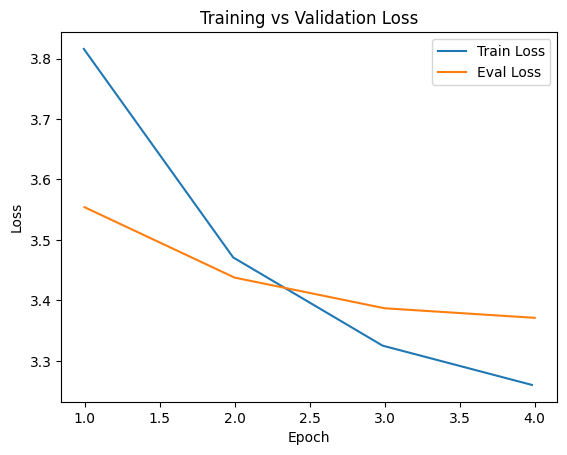

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

logs = trainer.state.log_history
df = pd.DataFrame(logs)

train_logs = df[df['loss'].notna()]
eval_logs = df[df['eval_loss'].notna()]

plt.plot(train_logs['epoch'], train_logs['loss'], label='Train Loss')
plt.plot(eval_logs['epoch'], eval_logs['eval_loss'], label='Eval Loss')
plt.legend()
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Training vs Validation Loss")
plt.show()

La anterior gráfica refleja el comportamiento de la perdida en entrenamiento y validación. En esta podemos observar que ambos valores disminuyen en el titempo durante las 4 epocas por lo que confirmamos que el modelo no se sobreajusta.

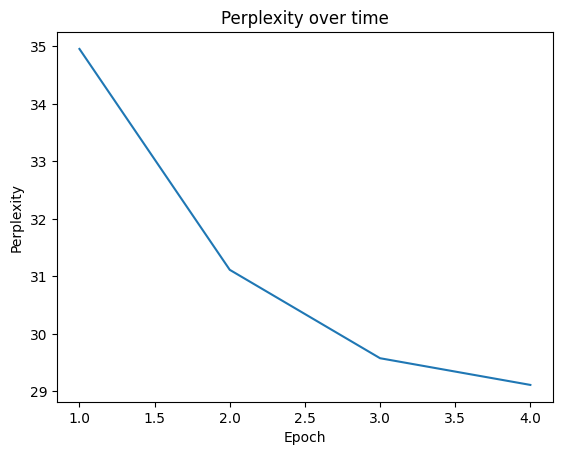

In [ ]:
eval_logs['perplexity'] = np.exp(eval_logs['eval_loss'])

plt.plot(eval_logs['epoch'], eval_logs['perplexity'])
plt.xlabel("Epoch")
plt.ylabel("Perplexity")
plt.title("Perplexity over time")
plt.show()

Segun la metrica de perplexity se puede observar que el modelo está aprendiendo y no hay overfitting ni underfitting.

In [ ]:
import collections
def count_and_display_repeated_words(text):
    words = text.lower().split()
    word_counts = collections.Counter(words)
    repeated_words = {word: count for word, count in word_counts.items() if count > 1}

    if repeated_words:
        print("Conteo de palabras iguales dentro del resultado generado:")
        for word, count in repeated_words.items():
            print(f"- '{word}': {count} times")
    else:
        print("No hay palabras repetidas en output_text.")

    return word_counts

word_counts_output_text = count_and_display_repeated_words(output_text)

Conteo de palabras iguales dentro del resultado generado:
- 'una': 4 times
- 'con': 3 times
- 'la': 3 times
- 'cama': 3 times
- 'de': 3 times
- 'y': 3 times
- 'sus': 2 times


Realizamos el conteo de palabras repetitivas debido a que en las pruebas realizadas observamos que en diversas ocasiones el resultado se quedaba en un loop de palabras repetidas hasta completar la cantidad solicitada de tokens.

Teniendo en cuenta lo anterior podemos inferir que el modelo no tuvo la capacidad de predecir el token de finalización pues se quedó en el loop de generar las mismas palabras. Adicionalmente, notamos que este comportamiento era común cuando el modelo presentaba overfitting.

## Conclusiones
- Observamos que tras el fine-tuning on `Balanced_AHR.csv` el modelo genera texto con un estilo claramente distinto al del modelo base. Ahora es mucho más frecuente encontrar estructuras propias de una reseña de hotel: menciones a la habitación, el servicio, la ubicación, etc. Sin embargo, los textos no tienen coherencia.
- El modelo `Amloii/gpt2-reviewspanish` parte ya de un dominio especializado (reseñas de productos en español), lo que reduce la distancia entre el pre-entrenamiento y el fine-tuning. Debido a que al realizar el mismo ejercicio con modelos sin especialización en reviews los resultados al aplicar fine-tuning con las reviews hoteleras eran desfavorables.
- Al configurar el modelo con temperaturas altas se obtienen reviews con poco sentido.
- La métrica perplexity es la métrica para modelos de lenguaje natural. Un valor decreciente durante el entrenamiento indica que el modelo se está especializando en el dominio del corpus. Por ejemplo, cuando realizamos la prueba con 10 epocas observamos que el modelo se sobreajustaba porque la métrica empezaba a crecer:
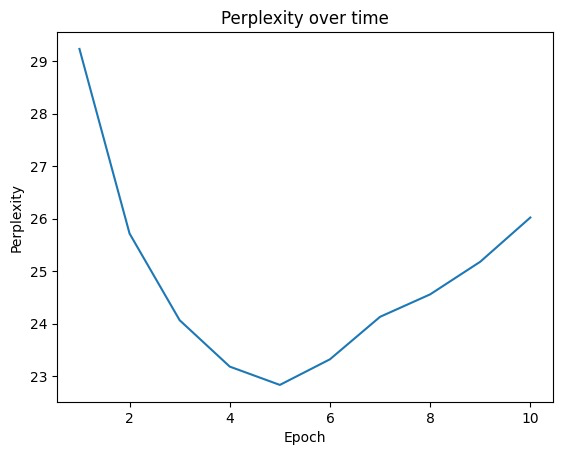

Este overfitting también se pudo evidenciar en la gráfica de perdida de entrenamiento y validación:
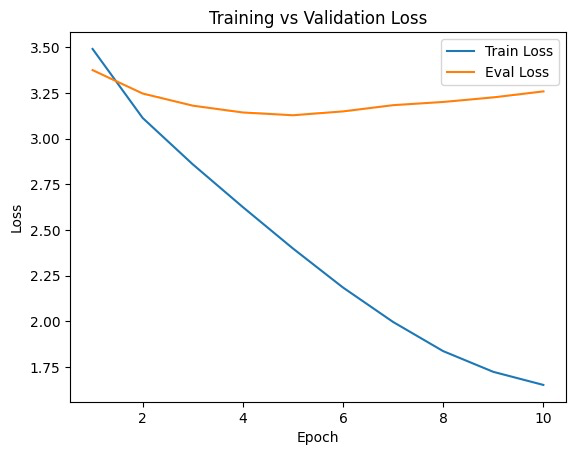

Es de resaltar que los modelos con overfitting como el anterior presentaban con frecuencia resultados con frases repetidas, en particular, siempre repetian la última frase generada.